In [1]:
import os

base_path = "/kaggle/input/datasets/salader/dogsvscats"

train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

print(train_path)
print(test_path)

/kaggle/input/datasets/salader/dogsvscats/train
/kaggle/input/datasets/salader/dogsvscats/test


In [2]:
import tensorflow as tf 
import keras 
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Rescaling, RandomFlip, RandomRotation,
    RandomZoom, RandomTranslation
)

from sklearn.metrics import accuracy_score
import cv2
import os

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np

import random

In [3]:
# generators (devides data into batches)
# use full for large impout of data

In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=train_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=test_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.


I0000 00:00:1785568998.678126      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 5000 files belonging to 2 classes.


# Training

## create CNN model 

In [5]:
model = Sequential([
    keras.layers.Input(shape=(256, 256, 3)),
    
    # Normalize pixel values
    Rescaling(1./255),

    # Data augmentation (applied only during training)
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.2),
    RandomTranslation(0.2, 0.2),

    # Convolution Block 1
    Conv2D(32, (3,3), activation='relu', padding='valid'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 256, 256, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
callback = EarlyStopping(
    monitor='val_loss', # watches validation loss each epoch
    verbose=1,
    patience=3,             
    restore_best_weights=True  # rolls back to the best epoch's weights when it stops
)

In [8]:
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])

In [9]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds,callbacks=callback)
# there are 625 batches

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 108ms/step - accuracy: 0.5433 - loss: 2.1854 - val_accuracy: 0.5452 - val_loss: 1.0493
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.5973 - loss: 0.6835 - val_accuracy: 0.6030 - val_loss: 0.6709
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.6507 - loss: 0.6438 - val_accuracy: 0.6398 - val_loss: 0.6413
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.6840 - loss: 0.6122 - val_accuracy: 0.7040 - val_loss: 0.5683
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.7110 - loss: 0.5870 - val_accuracy: 0.5430 - val_loss: 1.7726
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.7208 - loss: 0.5768 - val_accuracy: 0.7600 - val_loss: 0.5023
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.7357 - loss: 0.5579 - val_accuracy: 0.6946 - val_loss: 0.8538
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.7451 - loss: 0.5501 -

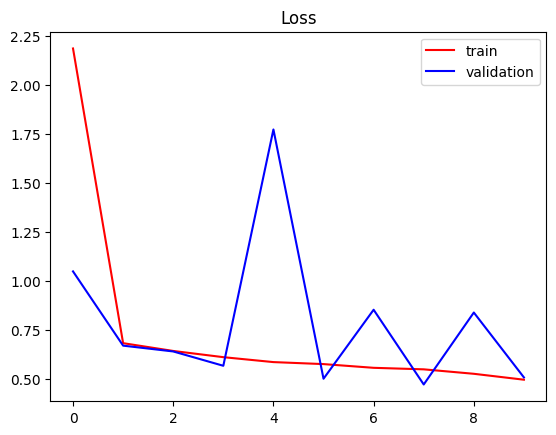

In [10]:
plt.title('Loss')
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

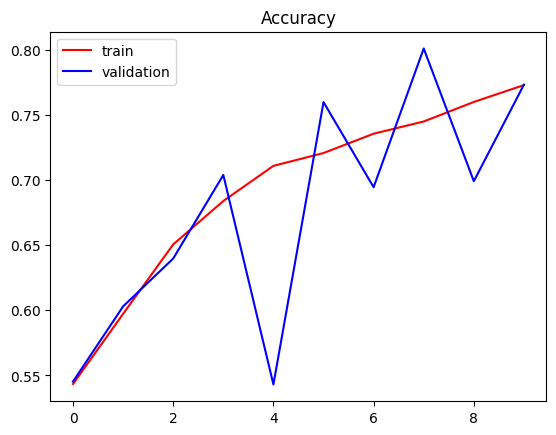

In [11]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [12]:
# ways to reduce overfitting 

# add more data
# data augmentation
# l1/l2 regularilization
# dropout
# Batch Normalization
# reduce model complexity

In [13]:
import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/marquis03/cats-and-dogs'):
    print(dirname,'\n',filenames)
    break

/kaggle/input/datasets/marquis03/cats-and-dogs 
 ['val.csv', 'train.csv']


In [14]:
df = pd.read_csv('/kaggle/input/datasets/marquis03/cats-and-dogs/val.csv')
df.head()

,image:FILE,category
0,val/cat/Persian_13_jpg.rf.dd6ccb81649242fcc8a2...,0
1,val/cat/Birman_137_jpg.rf.dc638a7840b71bfdcc9d...,0
2,val/cat/Siamese_142_jpg.rf.de98806682118bd0281...,0
3,val/cat/Birman_163_jpg.rf.de852821da3d65ebd262...,0
4,val/cat/Bengal_141_jpg.rf.e656908b712d2cb13742...,0


# Testing

In [15]:
import cv2

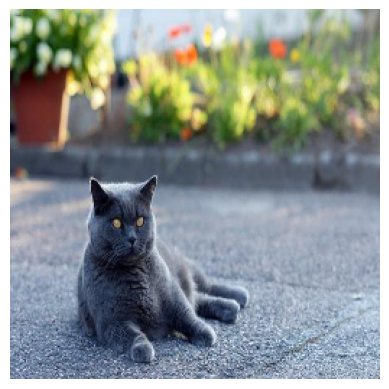

True: cat | Predicted: dog | Raw score: 0.9025


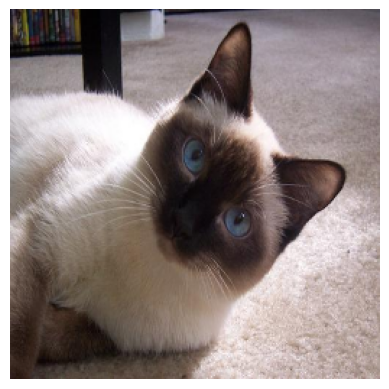

True: cat | Predicted: cat | Raw score: 0.2517


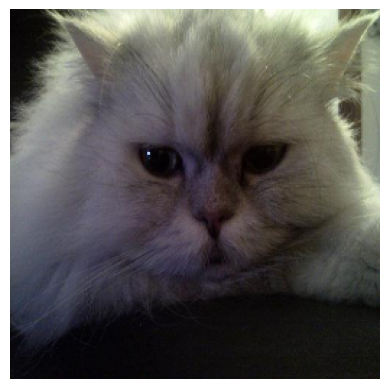

True: cat | Predicted: cat | Raw score: 0.3872


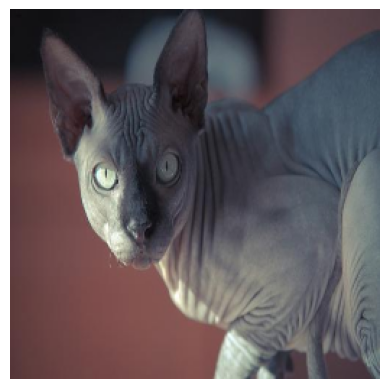

True: cat | Predicted: cat | Raw score: 0.4098


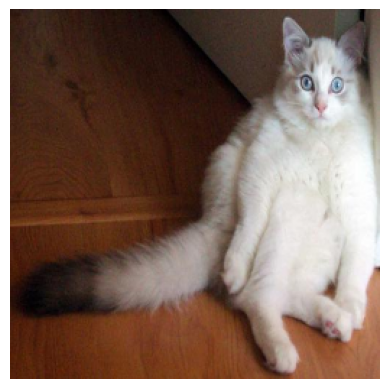

True: cat | Predicted: cat | Raw score: 0.3165


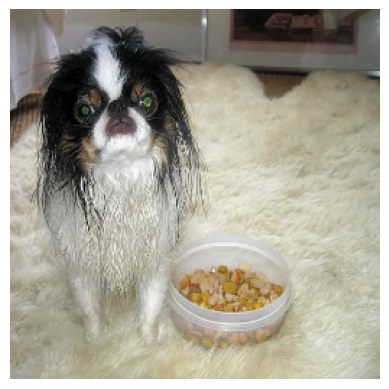

True: dog | Predicted: cat | Raw score: 0.3815


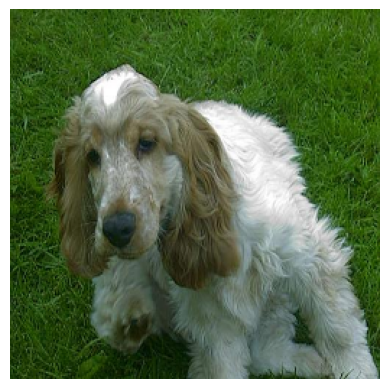

True: dog | Predicted: dog | Raw score: 0.9995


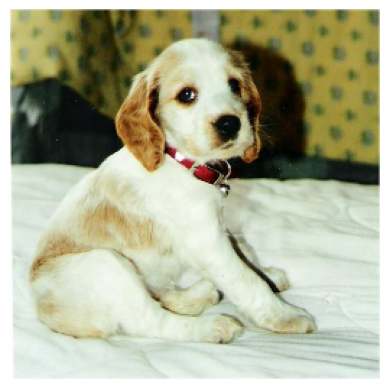

True: dog | Predicted: cat | Raw score: 0.3993


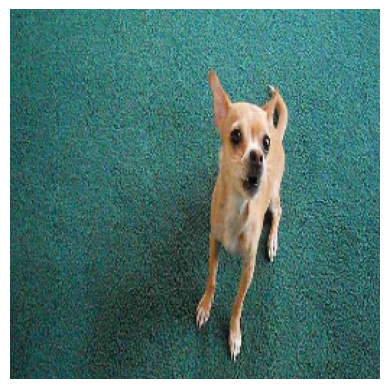

True: dog | Predicted: dog | Raw score: 0.9998


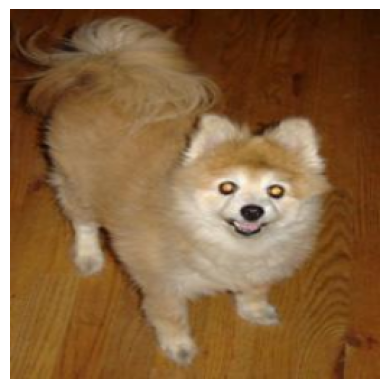

True: dog | Predicted: cat | Raw score: 0.4495


In [16]:
path = "/kaggle/input/datasets/marquis03/cats-and-dogs"

# Pick 5 cats (category == 0) and 5 dogs (category == 1) explicitly
cats_sample = df[df["category"] == 0].sample(5, random_state=None).reset_index(drop=True)
dogs_sample = df[df["category"] == 1].sample(5, random_state=None).reset_index(drop=True)
sample = pd.concat([cats_sample, dogs_sample]).reset_index(drop=True)

for _, row in sample.iterrows():
    image_path = os.path.join(path, row["image:FILE"])
    true_label = "dog" if row["category"] == 1 else "cat"

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # NOTE: no manual /255.0 here — the model already has a Rescaling(1./255) layer.
    # Feed it raw pixel values (0-255), just as float32.
    img_input = img.astype("float32")
    img_input = np.expand_dims(img_input, axis=0)

    prediction = model.predict(img_input, verbose=0)
    y_pred = np.where(prediction > 0.5, 1, 0)   # 0.5 is the standard threshold for sigmoid
    pred_label = "dog" if y_pred[0][0] == 1 else "cat"

    print(f"True: {true_label} | Predicted: {pred_label} | Raw score: {prediction[0][0]:.4f}")

In [17]:
train_ds.class_names

['cats', 'dogs']

In [18]:
path = "/kaggle/input/datasets/marquis03/cats-and-dogs"

y_true = []
y_pred = []

for _, row in df.iterrows():
    image_path = os.path.join(path, row["image:FILE"])

    # Read and preprocess image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))

    img_input = img.astype("float32")
    img_input = np.expand_dims(img_input, axis=0)

    # Prediction
    pred = model.predict(img_input, verbose=0)[0][0]

    predicted_label = 1 if pred > 0.5 else 0

    # Save labels
    y_true.append(row["category"])
    y_pred.append(predicted_label)

# Overall accuracy
accuracy = accuracy_score(y_true, y_pred)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

Validation Accuracy: 0.6000
Validation Accuracy: 60.00%


**check out my this note book with high accuracy (70% or above):** https://www.kaggle.com/code/hamidrana/dogvscats-using-alexnet-architecture